
**Financial PhraseBank** is specifically curated financial news sentences annotated by 16 financial analysts. The sentences come from:

Reuters financial news
Financial press releases
Earnings announcements

The "AllAgree" version you used means all 16 annotators agreed on the label — so the labels are very high quality and unambiguous.

In [5]:
# Block 1: Downloads FinancialPhraseBank zip directly from HuggingFace,
# extracts and parses the txt file. Saves CSV to Drive for persistence.

from google.colab import drive
drive.mount('/content/drive')

DRIVE_PATH = '/content/drive/MyDrive/finbert_finetune'
import os
os.makedirs(DRIVE_PATH, exist_ok=True)
print(f"✅ Drive mounted. Save path: {DRIVE_PATH}")

!pip install transformers datasets torch scikit-learn matplotlib seaborn -q

import pandas as pd
import zipfile
from huggingface_hub import hf_hub_download

CSV_FILE = f'{DRIVE_PATH}/phrasebank.csv'

if os.path.exists(CSV_FILE):
    print("📂 Loading dataset from Drive...")
    df = pd.read_csv(CSV_FILE)
else:
    print("⬇️  Downloading dataset from HuggingFace...")
    zip_path = hf_hub_download(
        repo_id="takala/financial_phrasebank",
        filename="data/FinancialPhraseBank-v1.0.zip",
        repo_type="dataset"
    )
    with zipfile.ZipFile(zip_path, 'r') as z:
        print(f"   Files in zip: {z.namelist()}")
        with z.open('FinancialPhraseBank-v1.0/Sentences_AllAgree.txt') as f:
            lines = []
            for line in f:
                line = line.decode('latin-1').strip()
                if '@' in line:
                    text, label = line.rsplit('@', 1)
                    lines.append({'text': text.strip(), 'label_name': label.strip()})

    df = pd.DataFrame(lines)
    label_map = {'negative': 0, 'neutral': 1, 'positive': 2}
    df['label'] = df['label_name'].map(label_map)
    df.to_csv(CSV_FILE, index=False)
    print(f"✅ Dataset saved to Drive")

print(f"\n── Dataset Summary ──")
print(f"   Total samples : {len(df)}")
print(f"\n── Class Distribution ──")
print(df['label_name'].value_counts())

print(f"\n── Sample sentences ──")
for label in ['negative', 'neutral', 'positive']:
    sample = df[df['label_name'] == label]['text'].iloc[0]
    print(f"\n   [{label.upper()}]: {sample}")

print("\n✅ Block 1 complete")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Drive mounted. Save path: /content/drive/MyDrive/finbert_finetune
⬇️  Downloading dataset from HuggingFace...


data/FinancialPhraseBank-v1.0.zip:   0%|          | 0.00/682k [00:00<?, ?B/s]

   Files in zip: ['FinancialPhraseBank-v1.0/', 'FinancialPhraseBank-v1.0/License.txt', '__MACOSX/', '__MACOSX/FinancialPhraseBank-v1.0/', '__MACOSX/FinancialPhraseBank-v1.0/._License.txt', 'FinancialPhraseBank-v1.0/README.txt', '__MACOSX/FinancialPhraseBank-v1.0/._README.txt', 'FinancialPhraseBank-v1.0/Sentences_50Agree.txt', 'FinancialPhraseBank-v1.0/Sentences_66Agree.txt', 'FinancialPhraseBank-v1.0/Sentences_75Agree.txt', 'FinancialPhraseBank-v1.0/Sentences_AllAgree.txt']
✅ Dataset saved to Drive

── Dataset Summary ──
   Total samples : 2264

── Class Distribution ──
label_name
neutral     1391
positive     570
negative     303
Name: count, dtype: int64

── Sample sentences ──

   [NEGATIVE]: Jan. 6 -- Ford is struggling in the face of slowing truck and SUV sales and a surfeit of up-to-date , gotta-have cars .

   [NEUTRAL]: According to Gran , the company has no plans to move all production to Russia , although that is where the company is growing .

   [POSITIVE]: For the last qua

In [6]:
# Block 2: Tokenizes text using DistilBERT tokenizer, splits into train/val/test,
# wraps in PyTorch DataLoaders ready for fine-tuning.

import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import DistilBertTokenizer
from sklearn.model_selection import train_test_split
import pickle

DRIVE_PATH = '/content/drive/MyDrive/finbert_finetune'
CSV_FILE   = f'{DRIVE_PATH}/phrasebank.csv'
DATA_FILE  = f'{DRIVE_PATH}/dataloaders.pkl'

df = pd.read_csv(CSV_FILE)
print(f"✅ Loaded {len(df)} samples")

# ── 1. Tokenizer ──────────────────────────────────────────────
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
print(f"✅ Tokenizer loaded")

# ── 2. Custom Dataset ─────────────────────────────────────────
class FinanceDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.encodings = tokenizer(
            list(texts), truncation=True, padding=True,
            max_length=max_len, return_tensors='pt'
        )
        self.labels = torch.tensor(list(labels), dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids'      : self.encodings['input_ids'][idx],
            'attention_mask' : self.encodings['attention_mask'][idx],
            'labels'         : self.labels[idx]
        }

# ── 3. Train / Val / Test split (70/15/15) ───────────────────
X_train, X_temp, y_train, y_temp = train_test_split(
    df['text'], df['label'], test_size=0.3, random_state=42, stratify=df['label']
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"✅ Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

# ── 4. Create DataLoaders ─────────────────────────────────────
train_loader = DataLoader(FinanceDataset(X_train, y_train, tokenizer), batch_size=16, shuffle=True)
val_loader   = DataLoader(FinanceDataset(X_val,   y_val,   tokenizer), batch_size=16)
test_loader  = DataLoader(FinanceDataset(X_test,  y_test,  tokenizer), batch_size=16)

print(f"✅ Train batches: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}")

# ── 5. Save to Drive ──────────────────────────────────────────
with open(DATA_FILE, 'wb') as f:
    pickle.dump({
        'train_loader' : train_loader,
        'val_loader'   : val_loader,
        'test_loader'  : test_loader,
        'X_test'       : list(X_test),
        'y_test'       : list(y_test)
    }, f)

print(f"✅ DataLoaders saved to Drive")
print("✅ Block 2 complete")

✅ Loaded 2264 samples


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

✅ Tokenizer loaded
✅ Train: 1584 | Val: 340 | Test: 340
✅ Train batches: 99 | Val: 22 | Test: 22
✅ DataLoaders saved to Drive
✅ Block 2 complete


In [8]:
# Block 3: Fine-tunes DistilBERT on financial sentiment classification.
# 5 epochs with early stopping on val loss. Saves best model to Drive.
# Fix: AdamW moved from transformers to torch.optim in newer versions.

import torch
import pickle
from transformers import DistilBertForSequenceClassification, get_linear_schedule_with_warmup
from torch.optim import AdamW
from sklearn.metrics import accuracy_score

DRIVE_PATH   = '/content/drive/MyDrive/finbert_finetune'
DATA_FILE    = f'{DRIVE_PATH}/dataloaders.pkl'
MODEL_DIR    = f'{DRIVE_PATH}/model'
RESULTS_FILE = f'{DRIVE_PATH}/training_results.pkl'

import os
os.makedirs(MODEL_DIR, exist_ok=True)

# ── 1. Load DataLoaders ───────────────────────────────────────
with open(DATA_FILE, 'rb') as f:
    saved = pickle.load(f)

train_loader = saved['train_loader']
val_loader   = saved['val_loader']
test_loader  = saved['test_loader']

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Training on: {device}")

# ── 2. Load pretrained DistilBERT ─────────────────────────────
model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=3    # negative, neutral, positive
)
model = model.to(device)
print(f"✅ Model loaded: {sum(p.numel() for p in model.parameters()):,} parameters")

# ── 3. Optimizer & scheduler ──────────────────────────────────
EPOCHS    = 5
optimizer = AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps   = len(train_loader),
    num_training_steps = len(train_loader) * EPOCHS
)

# ── 4. Training loop ──────────────────────────────────────────
def train_epoch(model, loader):
    model.train()
    total_loss, preds_all, labels_all = 0, [], []
    for batch in loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)
        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss    = outputs.loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()
        preds_all.extend(outputs.logits.argmax(dim=1).cpu().tolist())
        labels_all.extend(labels.cpu().tolist())
    return total_loss / len(loader), accuracy_score(labels_all, preds_all)

@torch.no_grad()
def eval_epoch(model, loader):
    model.eval()
    total_loss, preds_all, labels_all = 0, [], []
    for batch in loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        total_loss += outputs.loss.item()
        preds_all.extend(outputs.logits.argmax(dim=1).cpu().tolist())
        labels_all.extend(labels.cpu().tolist())
    return total_loss / len(loader), accuracy_score(labels_all, preds_all)

# ── 5. Run training ───────────────────────────────────────────
history  = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val = 0.0

print("\n── Training ──")
for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_epoch(model, train_loader)
    val_loss,   val_acc   = eval_epoch(model,  val_loader)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    if val_acc > best_val:
        best_val = val_acc
        model.save_pretrained(MODEL_DIR)
        print(f"   Epoch {epoch} | Train: {train_acc:.3f} | Val: {val_acc:.3f} ← best saved")
    else:
        print(f"   Epoch {epoch} | Train: {train_acc:.3f} | Val: {val_acc:.3f}")

# ── 6. Test evaluation ────────────────────────────────────────
model = DistilBertForSequenceClassification.from_pretrained(MODEL_DIR).to(device)
test_loss, test_acc = eval_epoch(model, test_loader)

print(f"\n── Results ──")
print(f"   Best Val Accuracy : {best_val:.3f}")
print(f"   Test Accuracy     : {test_acc:.3f}")

# ── 7. Save results ───────────────────────────────────────────
with open(RESULTS_FILE, 'wb') as f:
    pickle.dump({'history': history, 'best_val': best_val, 'test_acc': test_acc}, f)

print(f"\n✅ Model saved to: {MODEL_DIR}")
print("✅ Block 3 complete")

✅ Training on: cuda


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

   Epoch 3 | Train: 0.984 | Val: 0.968 ← best saved


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

   Epoch 4 | Train: 0.993 | Val: 0.974 ← best saved
   Epoch 5 | Train: 0.997 | Val: 0.971


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]


── Results ──
   Best Val Accuracy : 0.974
   Test Accuracy     : 0.956

✅ Model saved to: /content/drive/MyDrive/finbert_finetune/model
✅ Block 3 complete


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

✅ Model loaded

── Classification Report ──
              precision    recall  f1-score   support

    negative       0.96      0.93      0.95        46
     neutral       0.98      0.97      0.98       209
    positive       0.90      0.93      0.91        85

    accuracy                           0.96       340
   macro avg       0.94      0.95      0.94       340
weighted avg       0.96      0.96      0.96       340



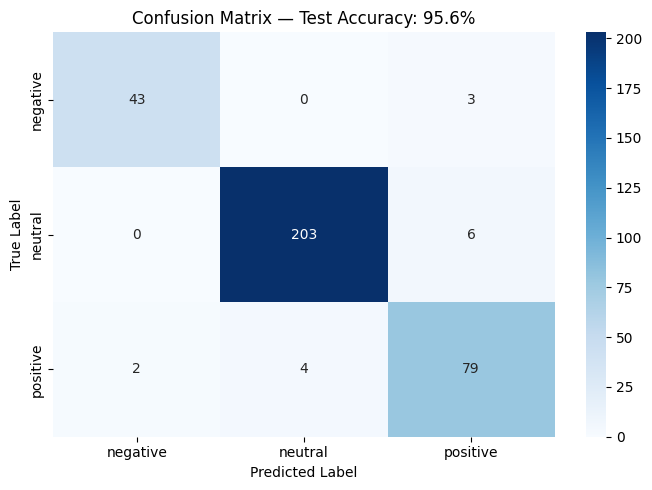

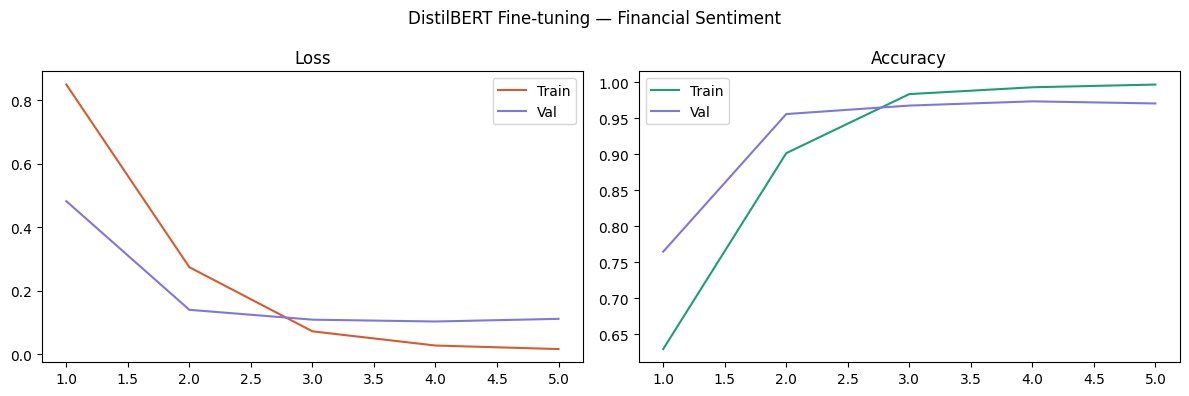


── Custom Sentence Predictions ──

   Text : The company reported record profits and raised its dividend....
   Pred : NEUTRAL
   Probs: {'negative': '0.4%', 'neutral': '92.8%', 'positive': '6.7%'}

   Text : Revenue declined sharply amid rising costs and weak demand....
   Pred : NEGATIVE
   Probs: {'negative': '99.2%', 'neutral': '0.4%', 'positive': '0.4%'}

   Text : The board approved the acquisition pending regulatory review....
   Pred : NEUTRAL
   Probs: {'negative': '0.1%', 'neutral': '99.7%', 'positive': '0.1%'}

   Text : Operating margins improved significantly in the third quarter....
   Pred : POSITIVE
   Probs: {'negative': '0.4%', 'neutral': '0.3%', 'positive': '99.3%'}

   Text : The firm filed for bankruptcy protection after debt negotiations faile...
   Pred : NEUTRAL
   Probs: {'negative': '3.3%', 'neutral': '96.3%', 'positive': '0.4%'}

✅ Saved confusion matrix and training curves to Drive
✅ Block 4 complete


In [9]:
# Block 4: Evaluates fine-tuned model with confusion matrix, classification report,
# and interactive testing on custom financial sentences.

import torch
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import DistilBertForSequenceClassification, DistilBertTokenizer
from sklearn.metrics import classification_report, confusion_matrix

DRIVE_PATH   = '/content/drive/MyDrive/finbert_finetune'
MODEL_DIR    = f'{DRIVE_PATH}/model'
RESULTS_FILE = f'{DRIVE_PATH}/training_results.pkl'
DATA_FILE    = f'{DRIVE_PATH}/dataloaders.pkl'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── 1. Load model and tokenizer ───────────────────────────────
model     = DistilBertForSequenceClassification.from_pretrained(MODEL_DIR).to(device)
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
model.eval()
print("✅ Model loaded")

# ── 2. Load results and test data ─────────────────────────────
with open(RESULTS_FILE, 'rb') as f:
    results = pickle.load(f)

with open(DATA_FILE, 'rb') as f:
    saved = pickle.load(f)

test_loader = saved['test_loader']
X_test      = saved['X_test']
y_test      = saved['y_test']

label_map   = {0: 'negative', 1: 'neutral', 2: 'positive'}
label_names = ['negative', 'neutral', 'positive']

# ── 3. Get predictions on test set ───────────────────────────
all_preds, all_labels = [], []

with torch.no_grad():
    for batch in test_loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)
        outputs        = model(input_ids=input_ids, attention_mask=attention_mask)
        preds          = outputs.logits.argmax(dim=1)
        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(labels.cpu().tolist())

# ── 4. Classification report ──────────────────────────────────
print("\n── Classification Report ──")
print(classification_report(all_labels, all_preds, target_names=label_names))

# ── 5. Confusion matrix ───────────────────────────────────────
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names)
plt.title(f'Confusion Matrix — Test Accuracy: {results["test_acc"]:.1%}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig(f'{DRIVE_PATH}/confusion_matrix.png', dpi=150)
plt.show()

# ── 6. Training curves ────────────────────────────────────────
history = results['history']
epochs  = list(range(1, len(history['train_loss']) + 1))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epochs, history['train_loss'], label='Train', color='#D85A30')
axes[0].plot(epochs, history['val_loss'],   label='Val',   color='#7F77DD')
axes[0].set_title('Loss'); axes[0].legend()

axes[1].plot(epochs, history['train_acc'], label='Train', color='#1D9E75')
axes[1].plot(epochs, history['val_acc'],   label='Val',   color='#7F77DD')
axes[1].set_title('Accuracy'); axes[1].legend()

plt.suptitle('DistilBERT Fine-tuning — Financial Sentiment')
plt.tight_layout()
plt.savefig(f'{DRIVE_PATH}/training_curves.png', dpi=150)
plt.show()

# ── 7. Test on custom sentences ───────────────────────────────
def predict(text):
    inputs = tokenizer(text, return_tensors='pt',
                       truncation=True, padding=True, max_length=128)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        logits = model(**inputs).logits
    probs = torch.softmax(logits, dim=1)[0].cpu().tolist()
    pred  = label_map[int(torch.argmax(logits))]
    return pred, {label_names[i]: f'{probs[i]:.1%}' for i in range(3)}

print("\n── Custom Sentence Predictions ──")
test_sentences = [
    "The company reported record profits and raised its dividend.",
    "Revenue declined sharply amid rising costs and weak demand.",
    "The board approved the acquisition pending regulatory review.",
    "Operating margins improved significantly in the third quarter.",
    "The firm filed for bankruptcy protection after debt negotiations failed."
]

for sentence in test_sentences:
    pred, probs = predict(sentence)
    print(f"\n   Text : {sentence[:70]}...")
    print(f"   Pred : {pred.upper()}")
    print(f"   Probs: {probs}")

print(f"\n✅ Saved confusion matrix and training curves to Drive")
print("✅ Block 4 complete")

In [12]:
import json
from google.colab import _message

# Get current notebook
nb = _message.blocking_request('get_ipynb', request='', timeout_sec=120)

# nb is already a dict, no need to json.loads
if 'ipynb' in nb:
    nb = nb['ipynb']

# Remove widget metadata
if 'widgets' in nb.get('metadata', {}):
    del nb['metadata']['widgets']
    print("✅ Removed widget metadata")

for cell in nb.get('cells', []):
    if 'widgets' in cell.get('metadata', {}):
        del cell['metadata']['widgets']

# Save fixed version to Drive
with open('/content/drive/MyDrive/finbert_finetune/FInancial_sentiment.ipynb', 'w') as f:
    json.dump(nb, f, indent=1)

print("✅ Fixed notebook saved to Drive")

✅ Removed widget metadata
✅ Fixed notebook saved to Drive
